In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import BatchNormalization
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)


In [ ]:
# Compatibility patch for legacy .h5 models that store BatchNorm renorm args
_original_bn_init = BatchNormalization.__init__


def _patched_bn_init(self, *args, **kwargs):
    kwargs.pop("renorm", None)
    kwargs.pop("renorm_clipping", None)
    kwargs.pop("renorm_momentum", None)
    return _original_bn_init(self, *args, **kwargs)


BatchNormalization.__init__ = _patched_bn_init

model = tf.keras.models.load_model("Models/EfficientNetB0/accident_model_efficientnet_b0.h5")

BatchNormalization.__init__ = _original_bn_init

test_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_generator = test_datagen.flow_from_directory(
    "data/Test",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False,
)


Found 3242 images belonging to 2 classes.


In [11]:
class_names = list(test_generator.class_indices.keys())
print(f"Class mapping: {test_generator.class_indices}")
print(f"Total test samples: {test_generator.samples}")


Class mapping: {'Accident': 0, 'NonAccident': 1}
Total test samples: 3242


In [12]:
steps = int(np.ceil(test_generator.samples / test_generator.batch_size))
probs = model.predict(test_generator, steps=steps, verbose=1)

y_true = test_generator.classes
y_pred = (probs.ravel() >= 0.5).astype(int)

102/102 ━━━━━━━━━━━━━━━━━━━━ 44s 409ms/step


In [13]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("=" * 40)
print("       MODEL EVALUATION RESULTS   ")
print("=" * 40)
print(f"  Accuracy:   {accuracy:.4f}  ({accuracy * 100:.2f}%)")
print(f"  Precision:  {precision:.4f}  ({precision * 100:.2f}%)")
print(f"  Recall:     {recall:.4f}  ({recall * 100:.2f}%)")
print(f"  F1 Score:   {f1:.4f}  ({f1 * 100:.2f}%)")
print("=" * 40)

print("\nConfusion matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification report:\n", classification_report(y_true, y_pred, target_names=class_names))

       MODEL EVALUATION RESULTS   
  Accuracy:   0.7134  (71.34%)
  Precision:  0.7134  (71.34%)
  Recall:     1.0000  (100.00%)
  F1 Score:   0.8328  (83.28%)

Confusion matrix:
 [[   0  929]
 [   0 2313]]

Classification report:
               precision    recall  f1-score   support

    Accident       0.00      0.00      0.00       929
 NonAccident       0.71      1.00      0.83      2313

    accuracy                           0.71      3242
   macro avg       0.36      0.50      0.42      3242
weighted avg       0.51      0.71      0.59      3242



c:\Users\paula\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\paula\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\paula\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

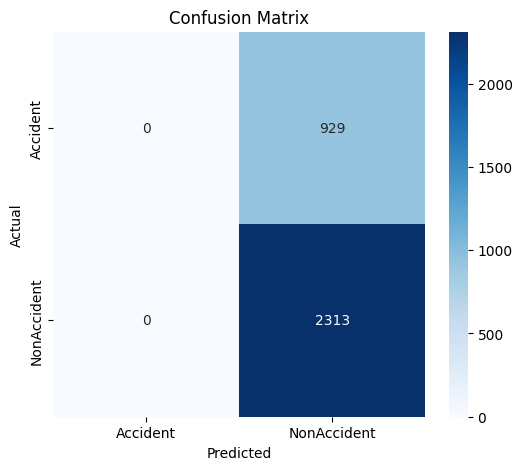

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

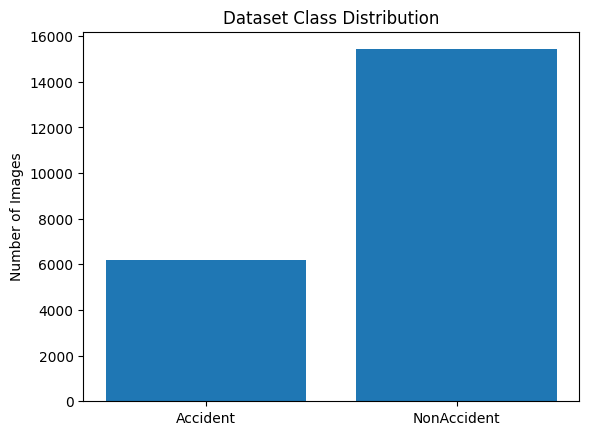

In [17]:
import matplotlib.pyplot as plt

labels = ['Accident','NonAccident']
values = [6191,15420]

plt.bar(labels, values)

plt.title("Dataset Class Distribution")
plt.ylabel("Number of Images")

plt.show()

In [1]:
print("Hello")

Hello
